<a href="https://colab.research.google.com/github/legong-beep/MPM_204_Gong/blob/main/labs/05_model_selection_inclass_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model slection exercise for *Solea solea* presence data

## *Solea solea* is a fish species

Data

**Dependent variable**: presence/ absence (1/0)

Covariates:
* Categorical: season, month, region
* Quantitative: depth, salinity, temperature, turbidity, mud sand, gravel etc

In [4]:
install.packages(c('MuMIn',"sjPlot"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [5]:
library(ggplot2)
library(dplyr)
library(sjPlot)

In [6]:
#Solea <- read.csv("C:/Users/prana/Desktop/directory/Applied-Veterinary-Population-Statistics/Week 3/Solea.csv")
Solea <- read.csv("/content/Solea.csv")
head(Solea)

,Sample,season,month,Area,depth,temperature,salinity,transparency,gravel,large_sand,med_fine_sand,mud,Solea_solea
,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,1,1,5,2,3.0,20,30,15,3.74,13.15,11.93,71.18,0
2,2,1,5,2,2.6,18,29,15,1.94,4.99,5.43,87.63,0
3,3,1,5,2,2.6,19,30,15,2.88,8.98,16.85,71.29,1
4,4,1,5,4,2.1,20,29,15,11.06,11.96,21.95,55.03,0
5,5,1,5,4,3.2,20,30,15,9.87,28.60,19.49,42.04,0
6,6,1,5,4,3.5,20,32,7,32.45,7.39,9.43,50.72,0


### Variable exploration

In [7]:
plotBinary <- function (X, Y, ...) {
     plot(X, jitter(Y, factor = 0.1), col = rgb(0, 0, 0, 0.5),
         pch = 19, ylim = c(-0.2, 1.2), ...)
     boxplot(X ~ Y, horizontal = TRUE, notch = TRUE, add = TRUE,
         at = c(-0.1, 1.1), width = c(0.1, 0.1), col = "grey",
         boxwex = 0.1, yaxt = "n")
}

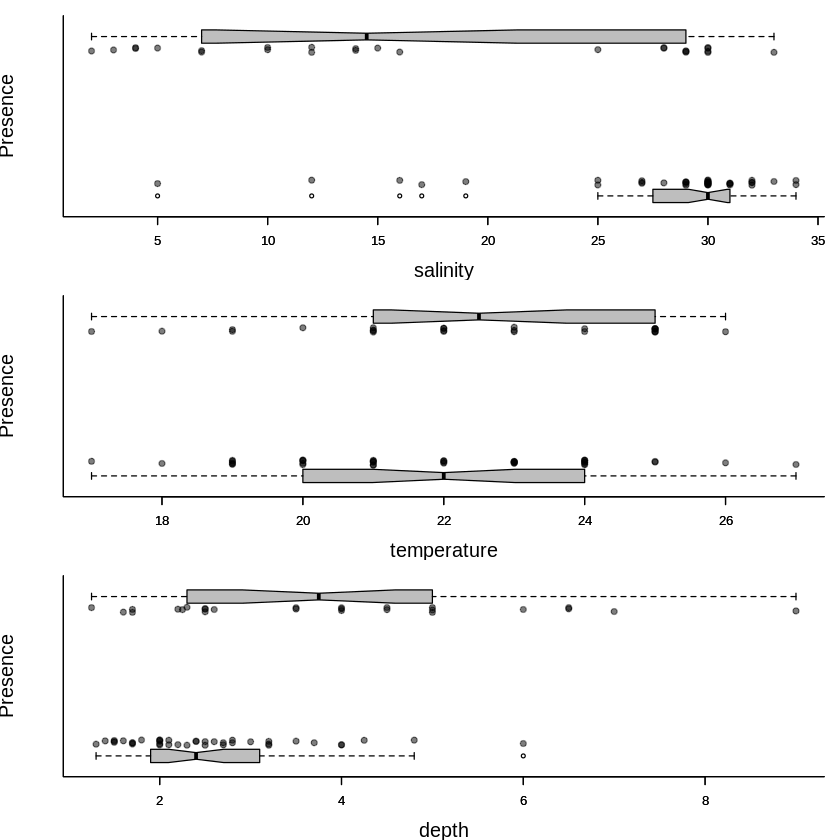

In [8]:
par(mfrow=c(3,1), bty="l", mar=c(4,4,1,1), cex.lab=1.5)
with(Solea, plotBinary(salinity, Solea_solea, xlab="salinity", ylab = "Presence", yaxt = "n"))
with(Solea, plotBinary(temperature, Solea_solea, xlab="temperature",   ylab = "Presence", yaxt = "n"))
with(Solea, plotBinary(depth, Solea_solea, xlab="depth", ylab = "Presence", yaxt = "n"))

Salinity does have much clear association/effect on presence /absence of Sole fish. Higher saline waters have higher 0 observations

## GLM fitting and model selection

In [9]:
f1 <- formula(Solea_solea~1)
f2 <- formula(Solea_solea~temperature)
f3 <- formula(Solea_solea~salinity)
f4 <- formula(Solea_solea~salinity+temperature)
f5 <- formula(Solea_solea~temperature*salinity)

We use **"Analysis of Deviance"** for nested glm models.   
* $D = 2(l_{model1} - l_{model0})$
* $l$ is log likelihood of the model
* in nested models, we test signficance of a terms, using Chi squared test

In [10]:
print(anova(glm(f5, family=binomial, data=Solea)))

Analysis of Deviance Table

Model: binomial, link: logit

Response: Solea_solea

Terms added sequentially (first to last)


                     Df Deviance Resid. Df Resid. Dev  Pr(>Chi)    
NULL                                    64     87.492              
temperature           1   0.8593        63     86.632   0.35394    
salinity              1  18.6567        62     67.976 1.565e-05 ***
temperature:salinity  1   3.2866        61     64.689   0.06985 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [11]:
help(anova)

In [12]:
print(anova(glm(f5, family=binomial, data=Solea), test = "Chi"))

Analysis of Deviance Table

Model: binomial, link: logit

Response: Solea_solea

Terms added sequentially (first to last)


                     Df Deviance Resid. Df Resid. Dev  Pr(>Chi)    
NULL                                    64     87.492              
temperature           1   0.8593        63     86.632   0.35394    
salinity              1  18.6567        62     67.976 1.565e-05 ***
temperature:salinity  1   3.2866        61     64.689   0.06985 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


* When we use the function to single model, the command gives reduction in residual deviance as each term of formula is added to the model sequentially.
* It is hence best to enter variables in decreasing signfiance.

In [13]:
print(anova(glm(Solea_solea ~ salinity +temperature + salinity * temperature, family=binomial, data=Solea), test = "Chi"))

Analysis of Deviance Table

Model: binomial, link: logit

Response: Solea_solea

Terms added sequentially (first to last)


                     Df Deviance Resid. Df Resid. Dev  Pr(>Chi)    
NULL                                    64     87.492              
salinity              1  18.9315        63     68.560 1.355e-05 ***
temperature           1   0.5845        62     67.976   0.44456    
salinity:temperature  1   3.2866        61     64.689   0.06985 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


### Compare models

In [14]:
print(anova(glm(f3, family=binomial, data=Solea),glm(f4, family=binomial, data=Solea),
      glm(f5, family=binomial, data=Solea), test = "Chi"))

Analysis of Deviance Table

Model 1: Solea_solea ~ salinity
Model 2: Solea_solea ~ salinity + temperature
Model 3: Solea_solea ~ temperature * salinity
  Resid. Df Resid. Dev Df Deviance Pr(>Chi)  
1        63     68.560                       
2        62     67.976  1   0.5845  0.44456  
3        61     64.689  1   3.2866  0.06985 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


## AIC (can be used for models that are not nested)

* Measure of fit
* High likelihood == better fit, and LOW AIC
* Can be used to compare models that are not nested

In [15]:
f3

Solea_solea ~ salinity

In [16]:
f2

Solea_solea ~ temperature

In [17]:
AIC(glm(f3, family=binomial, data=Solea),
    glm(f2, family=binomial, data=Solea))

,df,AIC
,<dbl>,<dbl>
"glm(f3, family = binomial, data = Solea)",2,72.55999
"glm(f2, family = binomial, data = Solea)",2,90.63224


In [18]:
require(plyr)
formulae <- list(f1, f2, f3, f4, f5)
solea.glms <- llply(formulae, function(f) glm(f, family=binomial, data=Solea))
names(solea.glms) <- formulae
ldply(solea.glms, AIC)

Loading required package: plyr

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘plyr’”


ERROR: Error in llply(formulae, function(f) glm(f, family = binomial, data = Solea)): could not find function "llply"


### Visualization

* Another great way of doing model exploration is through visualization
* We are just exploring the $B$s here, not odds of success

In [19]:
covariates <- names(Solea)[!( names(Solea) %in% c("Sample", "Area", "Solea_solea"))]
covariates

[1] "season"        "month"         "depth"         "temperature"  
 [5] "salinity"      "transparency"  "gravel"        "large_sand"   
 [9] "med_fine_sand" "mud"

### Writing a function for exploration of Betas

In [21]:
#creating a function
getBetaAndSe  <- function(covar)
    coef(summary(glm(Solea_solea ~ Solea[[covar]], data = Solea, family = "binomial")))[2,1:2]

In [22]:
getBetaAndSe("temperature")

Estimate Std. Error 
 0.1005642  0.1094649

In [23]:
# a Loop:
beta.table <- data.frame(variable = covariates, estimate = NA, se = NA)
for(i in 1:length(covariates))
    beta.table[i,2:3] <- getBetaAndSe(covar = covariates[i])

In [24]:
typeof(covariates)

[1] "character"

In [25]:
for(i in 1:length(covariates))
    print(covariates[i])

[1] "season"
[1] "month"
[1] "depth"
[1] "temperature"
[1] "salinity"
[1] "transparency"
[1] "gravel"
[1] "large_sand"
[1] "med_fine_sand"
[1] "mud"


In [26]:
beta.table

variable,estimate,se
<chr>,<dbl>,<dbl>
season,-0.69314718,0.51887448
month,-0.29569345,0.18581899
depth,0.61517036,0.21039401
temperature,0.10056417,0.10946492
salinity,-0.12985496,0.03494068
transparency,0.04343359,0.01754309
gravel,-0.01164669,0.02812472
large_sand,0.05465425,0.02077479
med_fine_sand,0.05263745,0.01886547


In [27]:
#CI. Is it crossing 0 or not? not significant if it does
beta.table <- mutate(beta.table, low = estimate - 2 * se, high = estimate + 2*se)
beta.table

variable,estimate,se,low,high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
season,-0.69314718,0.51887448,-1.730896142,0.34460178
month,-0.29569345,0.18581899,-0.667331431,0.07594452
depth,0.61517036,0.21039401,0.194382344,1.03595837
temperature,0.10056417,0.10946492,-0.118365678,0.31949402
salinity,-0.12985496,0.03494068,-0.199736314,-0.05997360
transparency,0.04343359,0.01754309,0.008347411,0.07851977
gravel,-0.01164669,0.02812472,-0.067896118,0.04460275
large_sand,0.05465425,0.02077479,0.013104667,0.09620382
med_fine_sand,0.05263745,0.01886547,0.014906517,0.09036838


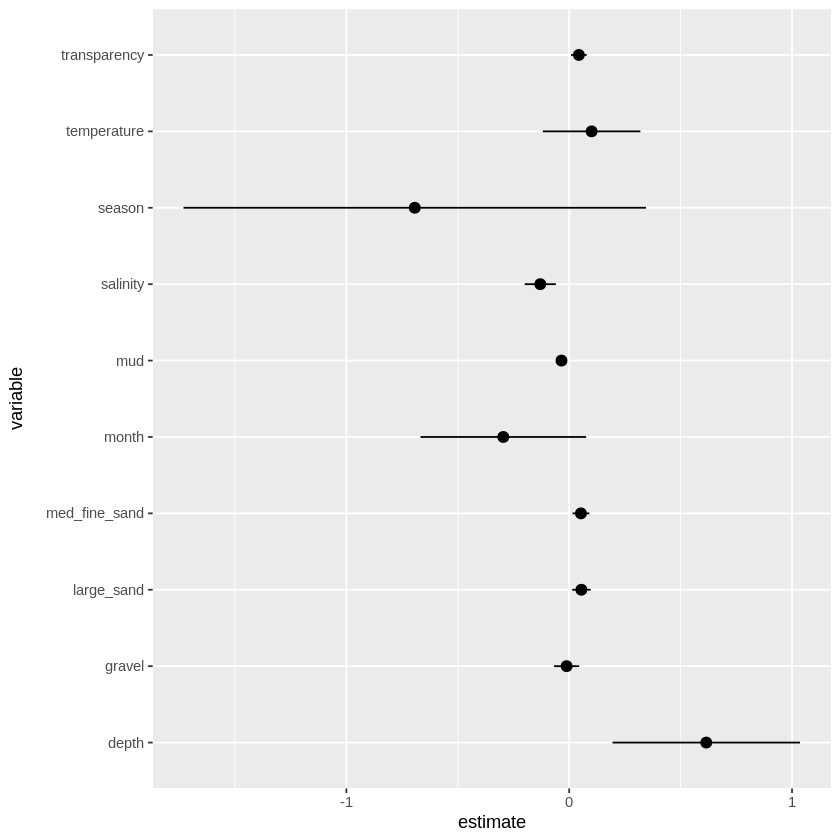

In [28]:
ggplot(beta.table, aes(y=estimate, x=variable, ymin=low, ymax=high)) + geom_pointrange() + coord_flip()
#just showing the betas together

* The issue here is that variables are all in different units
* Hence effect sizes are difficult to compare
* We will use scale function to transform them (only possible for quantitative variable)

In [ ]:
?scale

In [30]:
scale(Solea[temperature])

ERROR: Error: object 'temperature' not found


In [29]:
covariates <- names(Solea)[!( names(Solea) %in% c("Sample", "Area", "Solea_solea"))]
getBetaAndSe <- function(covar){
    coefs <- glm(Solea_solea ~ scale(Solea[[covar]]), data = Solea, family = "binomial") %>%
        summary %>% coef
    data.frame(variable = covar,
               estimate = coefs[2,1],
               se = coefs[2,2],
               p = coefs[2,4])
}

require(ggthemes)
beta.table <- adply(t(covariates), 2, getBetaAndSe) %>%
            arrange(estimate) %>%
            mutate(low = estimate - 2*se,
                         high = estimate + 2*se,
                         variable = reorder(variable, order(estimate)))

# note - the "reorder" was necessary to make the variables plot
# in the right order in ggplot ... but it took TOO LONG to figure out!

ggplot(beta.table, aes(y=estimate, x=variable, ymin=low, ymax=high, color = (p < 0.05))) +
            geom_pointrange() +
            geom_hline(yintercept = 0, col="darkgrey", lty = 3, lwd=2) +
            coord_flip() + theme_few() + ggtitle("Single main effect plot")


Loading required package: ggthemes

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘ggthemes’”


ERROR: Error in adply(t(covariates), 2, getBetaAndSe): could not find function "adply"


## Correlated covariates (Multicollinearity)

* Important to see if any covariates are closely correlated with each other
* We will do it through **pairs** plot
* just run multiple tests

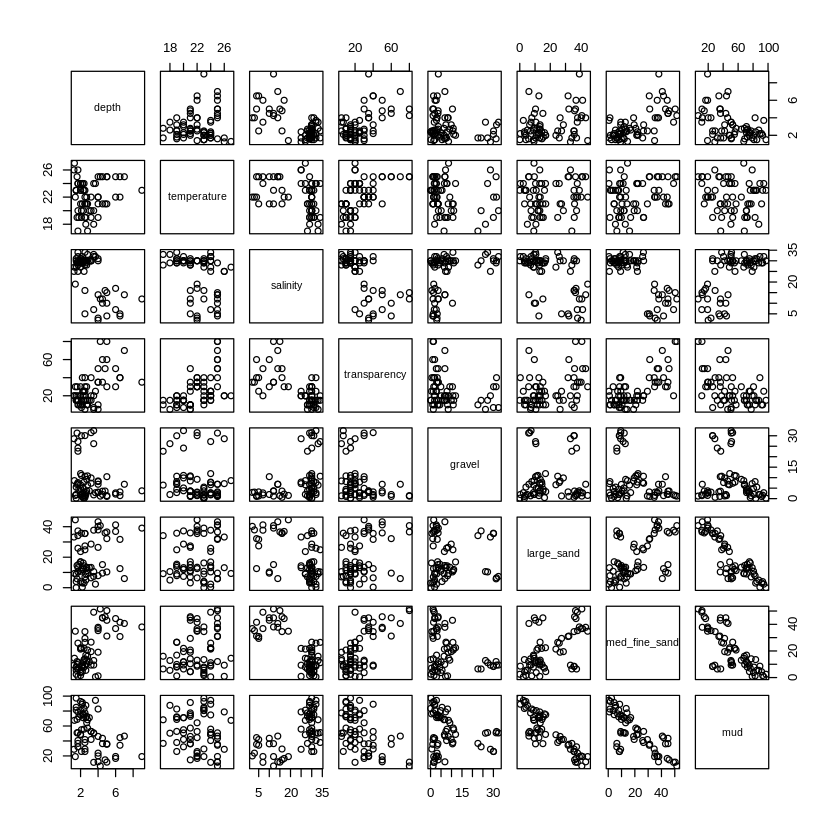

In [31]:
plot(Solea[5:12])

Two types of sands are well correlated with mud

In [32]:
cor(Solea[10:12])

,large_sand,med_fine_sand,mud
large_sand,1.0000000,0.5605420,-0.8717915
med_fine_sand,0.5605420,1.0000000,-0.7789052
mud,-0.8717915,-0.7789052,1.0000000


This suggests that we can limit our substrate covariates to JUST mud (which is a proxy for “not sand”), so our (reduced) data are:



In [33]:
Solea.redux <- Solea[,c(5:9,12:13)]

## Exploring multicollinearity post model fitting

VIF quantifies how much the variance of a regression coefficient is inflated due to multicollinearity with other predictors.

$$
\text{VIF}_j = \frac{1}{1 - R_j^2}
$$

If R² is low → VIF close to 1 → No multicollinearity.  
If R² is high → VIF large → Problematic multicollinearity.
For example:  
If R² = 0.8 → VIF = 1 / (1 - 0.8) = 5  
If R² = 0.9 → VIF = 1 / (1 - 0.9) = 10  

In [34]:
maineffects.glm <- glm(Solea_solea ~ ., family="binomial", data=Solea.redux)

In [41]:
install.packages('car')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [42]:
vif_values = car::vif(maineffects.glm)
vif_values

depth  temperature     salinity transparency       gravel          mud 
    1.908275     1.754877     4.356766     2.840829     2.048546     2.977423

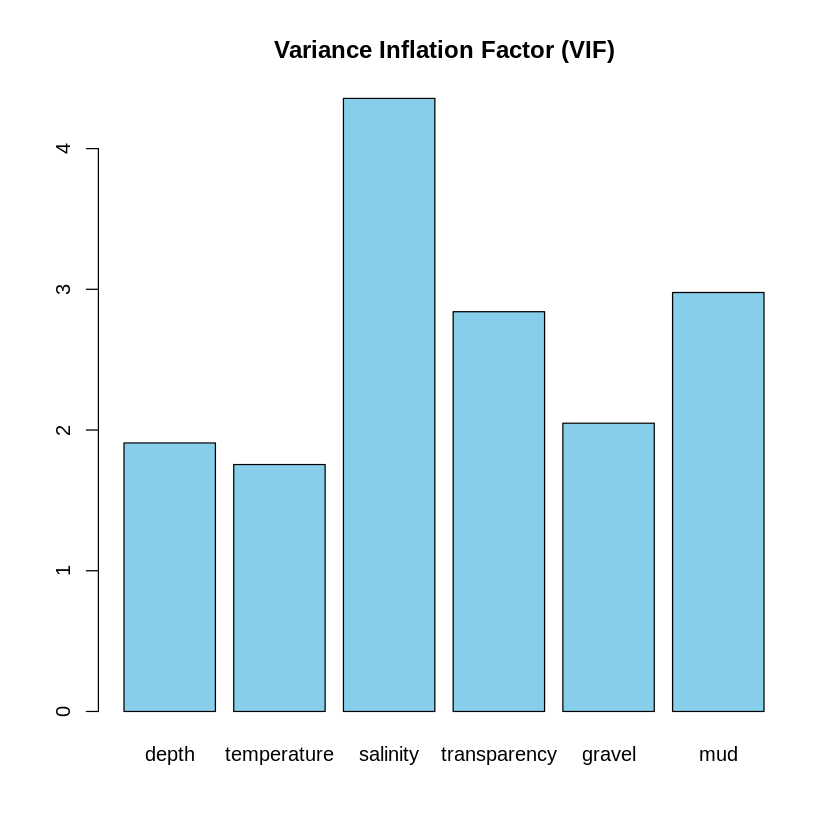

In [43]:
barplot(vif_values, col = "skyblue", main = "Variance Inflation Factor (VIF)")

## Inlcude everything with single command in R

In [44]:
maineffects.glm <- glm(Solea_solea ~ ., family="binomial", data=Solea.redux)

In [47]:
Solea.redux.scaled <- data.frame(scale(Solea.redux[,1:6]),
                                 Solea_solea = Solea.redux$Solea_solea)
me.glm.scaled <- glm(Solea_solea ~ ., family="binomial", data=Solea.redux.scaled)

beta.table <- data.frame(summary(me.glm.scaled)$coef)
beta.table$variable <- row.names(beta.table)
beta.table <- mutate(beta.table, estimate = Estimate,
                 se = Std..Error,
           low = Estimate - 2*se,
                 high = Estimate + 2*se,
                 p = Pr...z..)

ggplot(beta.table, aes(y=estimate, x=variable, ymin=low, ymax=high, color = (p < 0.05))) +
            geom_pointrange() +
            geom_hline(yintercept = 0, col="darkgrey", lty = 3, lwd=2) +
            coord_flip() + theme_few() + ggtitle("Multiple main effect plot")

ERROR: Error in theme_few(): could not find function "theme_few"


Analysis of deviance for main effects model

In [46]:
print(anova(maineffects.glm, test="Chi"))

Analysis of Deviance Table

Model: binomial, link: logit

Response: Solea_solea

Terms added sequentially (first to last)


             Df Deviance Resid. Df Resid. Dev Pr(>Chi)    
NULL                            64     87.492             
depth         1  11.3487        63     76.143 0.000755 ***
temperature   1   0.2190        62     75.924 0.639765    
salinity      1   8.1295        61     67.794 0.004355 ** 
transparency  1   0.0365        60     67.758 0.848523    
gravel        1   2.0728        59     65.685 0.149951    
mud           1   0.3753        58     65.310 0.540107    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


* It looks like only depth and salinity are really significant players here.
* The stepAIC function (in MASS) uses AIC as a criterion to march through the inclusion and removal of different covariates to find the one with lowest AIC.

In [ ]:
?stepAIC

In [48]:
maineffects.glm


Call:  glm(formula = Solea_solea ~ ., family = "binomial", data = Solea.redux)

Coefficients:
 (Intercept)         depth   temperature      salinity  transparency  
   4.6943973     0.1138113    -0.1049369    -0.1820749    -0.0005358  
      gravel           mud  
   0.0637049     0.0128290  

Degrees of Freedom: 64 Total (i.e. Null);  58 Residual
Null Deviance:	    87.49 
Residual Deviance: 65.31 	AIC: 79.31

In [49]:
require(MASS)
best.main.glm <- stepAIC(maineffects.glm)

Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select




Start:  AIC=79.31
Solea_solea ~ depth + temperature + salinity + transparency + 
    gravel + mud

               Df Deviance    AIC
- transparency  1   65.310 77.310
- depth         1   65.477 77.477
- mud           1   65.685 77.685
- temperature   1   65.722 77.722
<none>              65.310 79.310
- gravel        1   67.603 79.603
- salinity      1   72.965 84.965

Step:  AIC=77.31
Solea_solea ~ depth + temperature + salinity + gravel + mud

              Df Deviance    AIC
- depth        1   65.489 75.489
- mud          1   65.730 75.730
- temperature  1   65.883 75.883
<none>             65.310 77.310
- gravel       1   67.683 77.683
- salinity     1   73.011 83.011

Step:  AIC=75.49
Solea_solea ~ temperature + salinity + gravel + mud

              Df Deviance    AIC
- mud          1   65.884 73.884
- temperature  1   66.229 74.229
<none>             65.489 75.489
- gravel       1   67.846 75.846
- salinity     1   76.752 84.752

Step:  AIC=73.88
Solea_solea ~ temperature + sali

In [ ]:
#model above moves the variables to find lower AIC


It seems to like the salinity and gravel main effects model.

### Interactions

In [50]:
interactions.glm <- glm(Solea_solea ~ (.)^2, family="binomial", data=Solea.redux)
best.interaction.glm <- stepAIC(interactions.glm, trace = 0)
print(anova(best.interaction.glm, test = "Chi"))

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Analysis of Deviance Table

Model: binomial, link: logit

Response: Solea_solea

Terms added sequentially (first to last)


                         Df Deviance Resid. Df Resid. Dev Pr(>Chi)    
NULL                                        64     87.492             
depth                     1  11.3487        63     76.143 0.000755 ***
temperature               1   0.2190        62     75.924 0.639765    
salinity                  1   8.1295        61     67.794 0.004355 ** 
transparency              1   0.0365        60     67.758 0.848523    
gravel                    1   2.0728        59     65.685 0.149951    
mud                       1   0.3753        58     65.310 0.540107    
depth:salinity            1   3.9958        57     61.314 0.045612 *  
depth:gravel              1   0.0336        56     61.280 0.854576    
depth:mud                 1   2.5044        55     58.776 0.113527    
temperature:salinity      1   3.9134        54     54.862 0.047902 *  
temperature:transparency

In [51]:
summary(best.interaction.glm)


Call:
glm(formula = Solea_solea ~ depth + temperature + salinity + 
    transparency + gravel + mud + depth:salinity + depth:gravel + 
    depth:mud + temperature:salinity + temperature:transparency + 
    salinity:transparency + gravel:mud, family = "binomial", 
    data = Solea.redux)

Coefficients:
                           Estimate Std. Error z value Pr(>|z|)  
(Intercept)              -45.712222  48.452781  -0.943   0.3455  
depth                      4.001372   2.667924   1.500   0.1337  
temperature                2.168823   2.259803   0.960   0.3372  
salinity                   2.585277   1.871887   1.381   0.1672  
transparency              -1.335798   0.898259  -1.487   0.1370  
gravel                     0.018782   0.223730   0.084   0.9331  
mud                       -0.110634   0.095543  -1.158   0.2469  
depth:salinity            -0.312938   0.188335  -1.662   0.0966 .
depth:gravel               0.122340   0.094873   1.290   0.1972  
depth:mud                  0.058954 

In [ ]:
#nothing significant in these results, so go back and look into if the interactions improve the deviance
#depth, salinity, depth:salinity, gravel:mud are significant

In [52]:
final_interaction_glm(formula = Solea_solea ~ depth + temperature + salinity +
  gravel + mud + temperature:salinity + gravel:mud, family = "binomial",
    data = Solea.redux)

ERROR: Error in final_interaction_glm(formula = Solea_solea ~ depth + temperature + : could not find function "final_interaction_glm"


* There are multiple interactions that appear significant, and the residual deviance of 46.6 really does seem low.
* HOWEVER, we only have 65 rows of data! And six possible covariates … leading to 1 + 6 + 6*6 = 43 parameters to fit!
* This is almost certainly a case of serious overfitting, and a somewhat spurious result.

* we use AICc: for small sample sizes
* We run dredge function in MuMIn package to fit every possible combination of all varibles
* and then assess the best model

In [55]:
#install.packages("MuMIn", type = "binary")
library(MuMIn)
#helps ID which covariates stay

In [56]:
#install.packages("MuMin", type ='binary')

ERROR: Error in install.packages("MuMin", type = "binary"): type 'binary' is not supported on this platform


In [ ]:
?dredge

In [57]:
require(MuMIn)
maineffects.glm <- glm(Solea_solea ~ ., family="binomial", data=Solea.redux, na.action = na.pass)
mega.model.comparison <- dredge(maineffects.glm)
print(mega.model.comparison)

Fixed term is "(Intercept)"



Global model call: glm(formula = Solea_solea ~ ., family = "binomial", data = Solea.redux, 
    na.action = na.pass)
---
Model selection table 
   (Intrc)  depth     gravl       mud   slnty     tmprt      trnsp df  logLik
9   2.6610                            -0.1299                       2 -34.280
11  2.7460         0.047430           -0.1509                       3 -33.242
25  5.2180                            -0.1412 -0.103300             3 -33.988
27  5.3710         0.047860           -0.1633 -0.105500             4 -32.942
10  1.8370 0.1416                     -0.1136                       3 -34.127
13  2.7170                  -0.006696 -0.1178                       3 -34.185
41  3.1560                            -0.1416           -0.0080660  3 -34.219
12  1.9480 0.1371  0.047140           -0.1350                       4 -33.099
15  2.7150         0.059700  0.009794 -0.1746                       4 -33.114
43  3.3080         0.047850           -0.1645           -0.0089310  4 -33.16

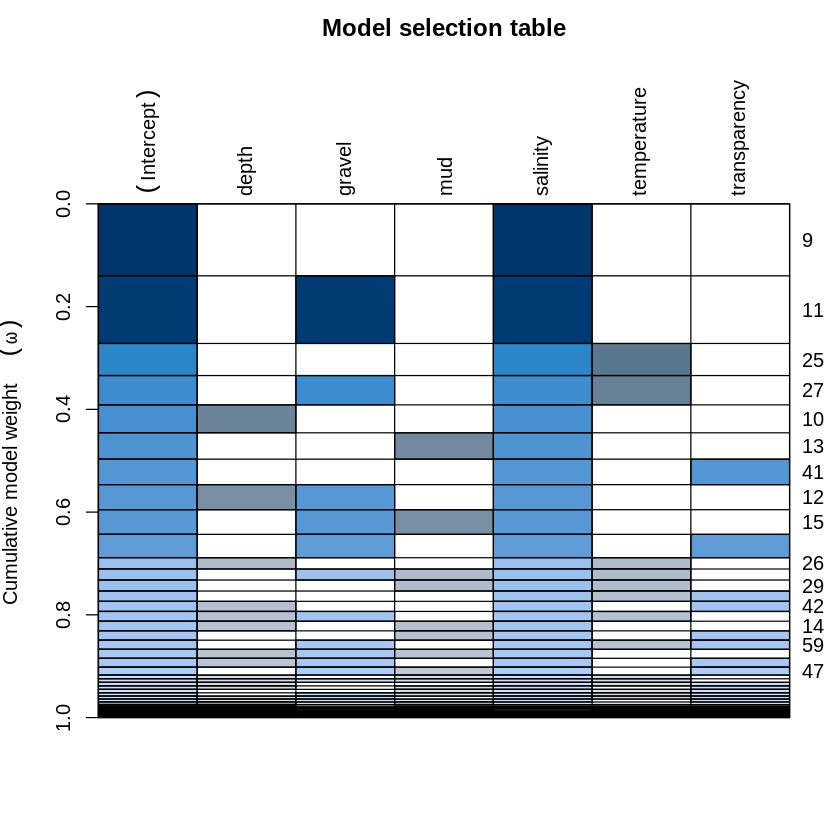

In [58]:
plot(mega.model.comparison)

In [ ]:
#darker color=higher weights
#